<a href="https://colab.research.google.com/github/Sagar122198/ML/blob/main/ML%20project%20demo2(gemini).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model Accuracy: 55.77%

Detailed Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.25      0.34      9127
           1       0.56      0.81      0.67     10873

    accuracy                           0.56     20000
   macro avg       0.55      0.53      0.50     20000
weighted avg       0.55      0.56      0.52     20000



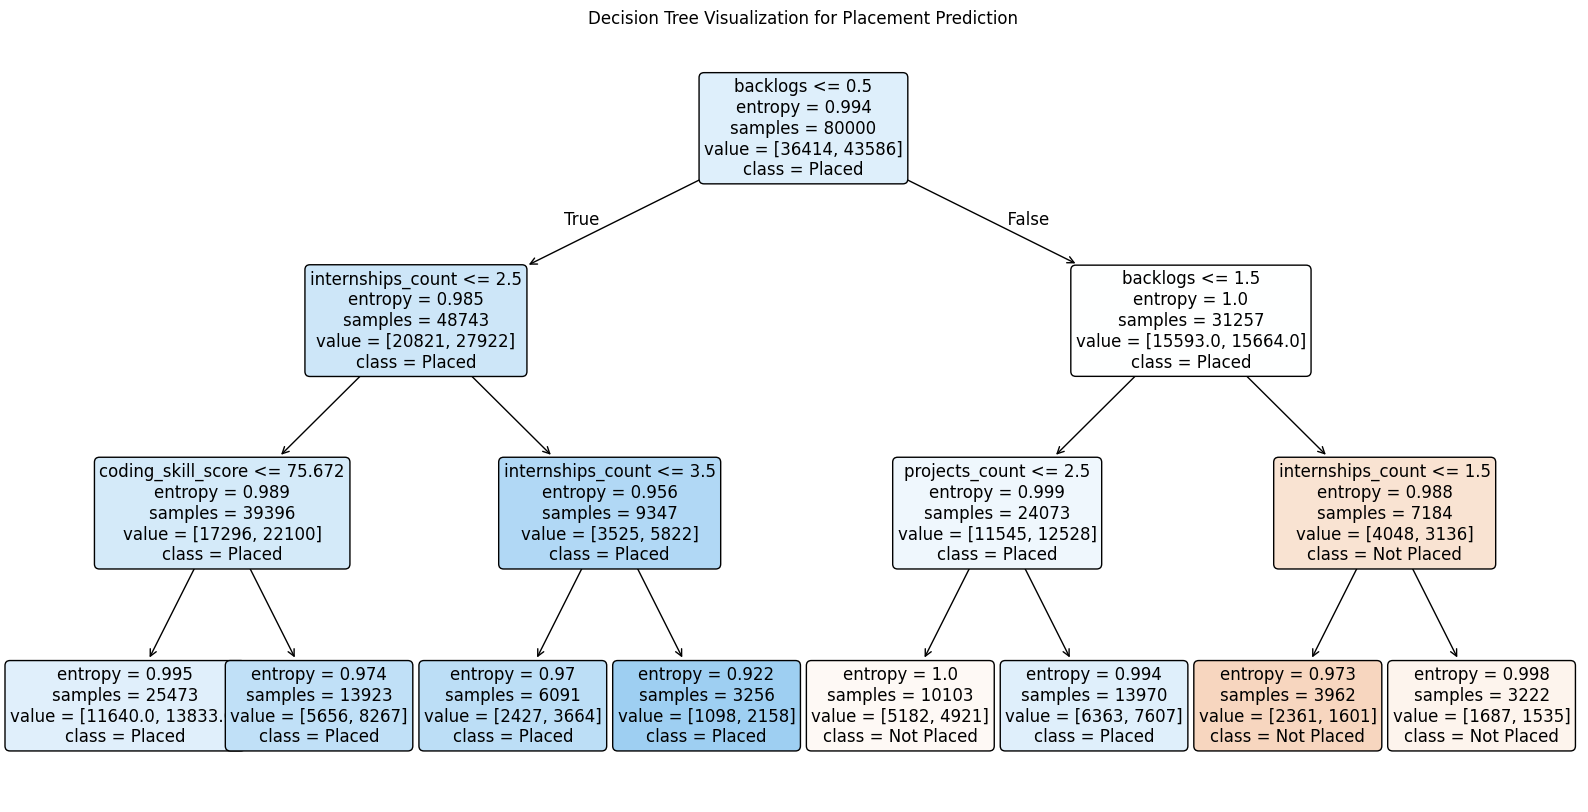

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
# Ensure the file 'student_placement.csv' is uploaded to your Colab environment
df = pd.read_csv('student_placement.csv')

# 2. Data Preprocessing
# Convert categorical text columns into numbers so the algorithm can process them
le = LabelEncoder()
categorical_cols = ['gender', 'branch', 'college_tier', 'volunteer_experience', 'placement_status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# 3. Define Features and Target
# 'student_id' is an identifier and 'salary_package_lpa' is a post-placement result,
# so they are excluded from the features.
X = df.drop(columns=['student_id', 'placement_status', 'salary_package_lpa'])
y = df['placement_status']

# 4. Split the data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and Train the Decision Tree
# 'max_depth' is set to 3 to keep the tree simple and explainable for a viva.
# 'criterion' is set to 'entropy' to measure the quality of the split.
model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
model.fit(X_train, y_train)

# 6. Make Predictions and Evaluate
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred))

# 7. Visualize the Decision Tree




plt.figure(figsize=(20,10))
plot_tree(model,
          feature_names=X.columns,
          class_names=['Not Placed', 'Placed'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Decision Tree Visualization for Placement Prediction")
plt.show()